In [1]:
from matplotlib import pyplot as plt
from dataset import load_dataset
from sklearn.feature_selection import f_regression
plt.style.use("default")
from plot_style import set_plot_style
set_plot_style()
from sklearn.preprocessing import MinMaxScaler
from regression.RandomForest.random_forest_regression import RandomForestRegressorModel
import pandas as pd

In [2]:
TRAIN_PATH_FULL = "../../data/processed/full_train/train.csv"
TRAIN_PATH_SPLIT = "../../data/processed/split_85_15/train_85.csv"
TEST_PATH_SPLIT  = "../../data/processed/split_85_15/test_15.csv"
TARGET_COL_MARGIN = "trq_margin"
TARGET_COL_TARGET = "trq_target"
FEUTURE=["oat","pa","np_ng_ratio","ias","mgt","trq_measured"]

In [3]:
train_df=load_dataset(TRAIN_PATH_SPLIT)
test_df=load_dataset(TEST_PATH_SPLIT)

## Tourque target


<Axes: >

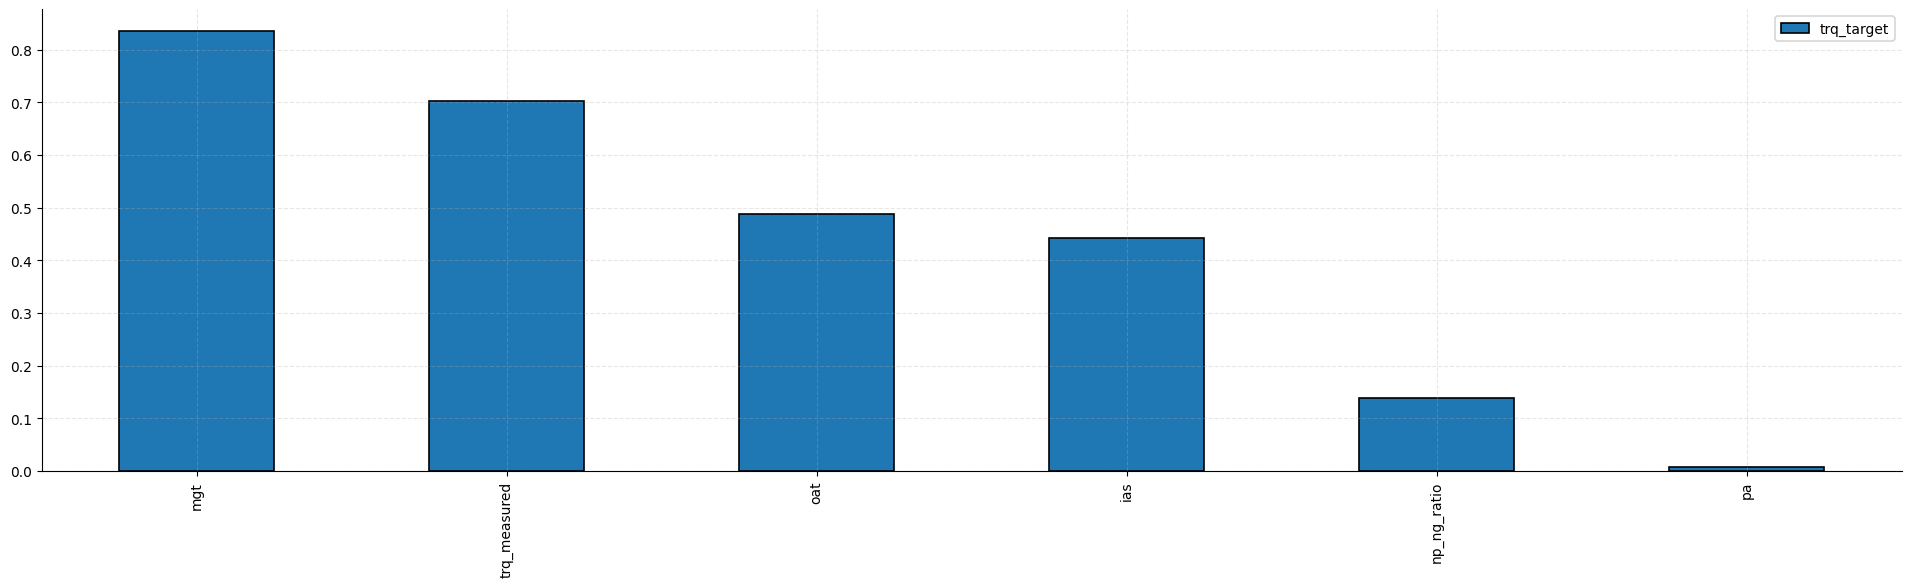

In [4]:
corr_with_target = (
    train_df.corr()[['trq_target']]
    .drop(index=['trq_margin','faulty','trq_target'])
).abs().sort_values(by='trq_target', ascending=False)
corr_with_target.plot(kind='bar', figsize=(24, 6))

<Axes: >

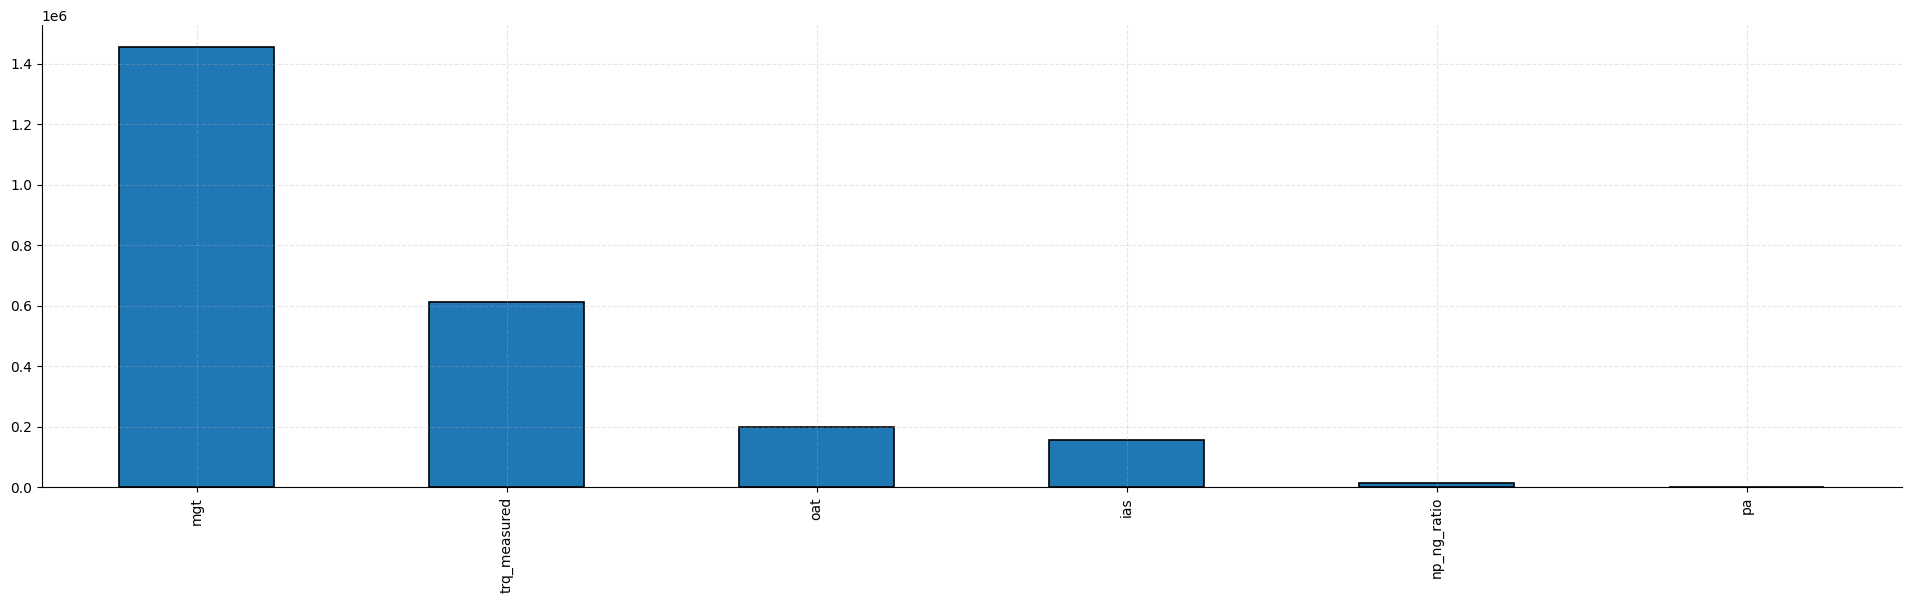

In [5]:
prova=train_df.copy()
F, p_values = f_regression(prova.drop(['trq_target','faulty','trq_margin'],axis=1), prova['trq_target'])
f_scores = pd.Series(F, index=prova.drop(['trq_target','faulty','trq_margin'],axis=1).columns).sort_values(ascending=False)
f_scores.plot(kind='bar', figsize=(24, 6))

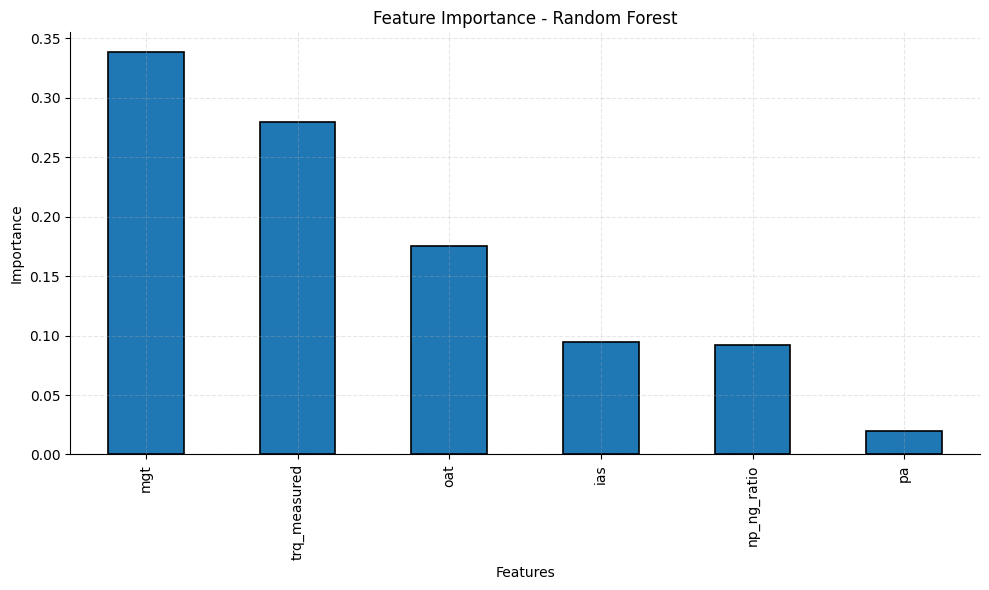

In [6]:
X_train = train_df[FEUTURE].values
y_train = train_df[TARGET_COL_TARGET].values

X_test = test_df[FEUTURE].values
y_test= test_df[TARGET_COL_TARGET].values

rf = RandomForestRegressorModel(
    n_estimators=500,
    min_samples_leaf=5,

)
rf.fit(X_train, y_train)

importances = rf.model.feature_importances_
feat_imp = pd.Series(importances, index=FEUTURE)
feat_imp = feat_imp.sort_values(ascending=False)

plt.figure(figsize=(10, 6))
feat_imp.plot(kind='bar')
plt.title("Feature Importance - Random Forest")
plt.ylabel("Importance")
plt.xlabel("Features")
plt.tight_layout()
plt.show()

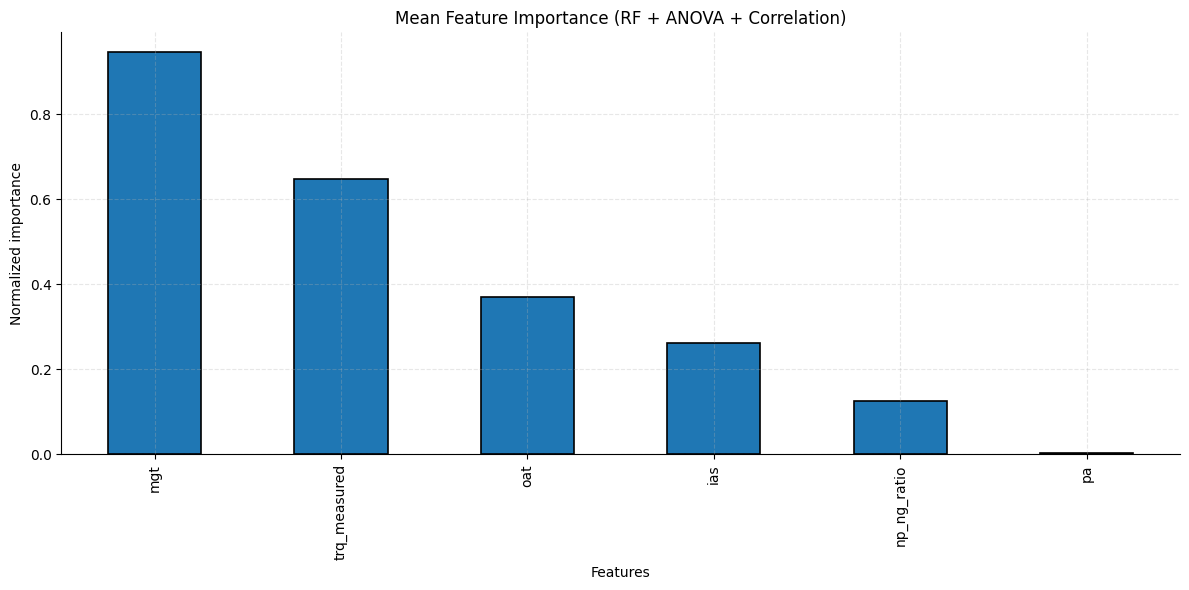

In [7]:
feat_imp.name = "RF"
f_scores.name = "ANOVA"
corr_with_target.name = "Correlation"

feat_compare = pd.concat(
    [feat_imp, f_scores, corr_with_target],
    axis=1
)

scaler = MinMaxScaler()

scaler = MinMaxScaler()

feat_compare["ANOVA"] = scaler.fit_transform(
    feat_compare[["ANOVA"]]
)
feat_compare["RF"] = scaler.fit_transform(
    feat_compare[["RF"]]
)
feat_compare["Mean_importance"] = feat_compare.mean(axis=1)

feat_norm = feat_compare.sort_values(
    "Mean_importance",
    ascending=False
)

plt.figure(figsize=(12, 6))

feat_norm["Mean_importance"].plot(kind="bar")

plt.title("Mean Feature Importance (RF + ANOVA + Correlation)")
plt.ylabel("Normalized importance")
plt.xlabel("Features")
plt.tight_layout()
plt.show()

Tourque Margin

<Axes: >

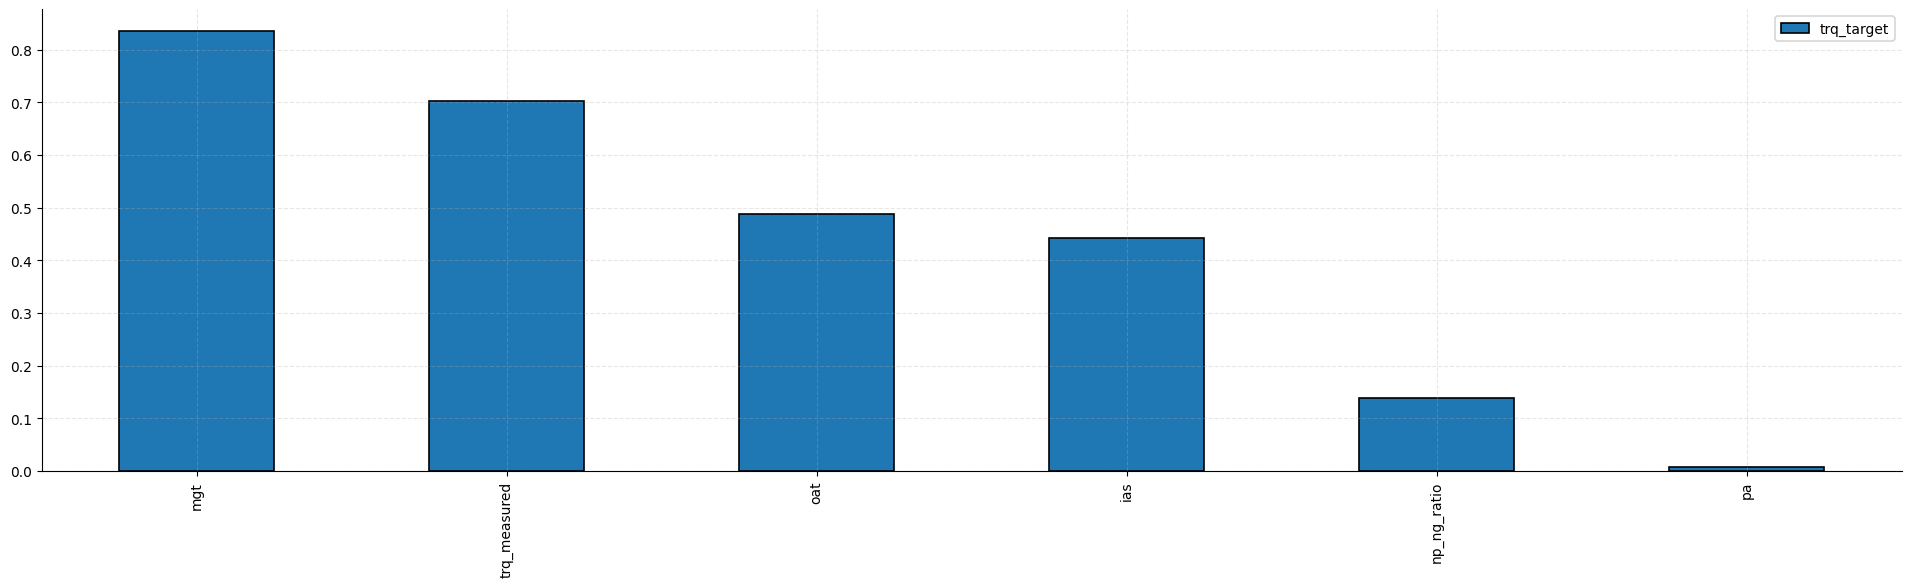

In [20]:
corr_with_margin = (
    train_df.corr()[['trq_margin']]
    .drop(index=['trq_margin','faulty','trq_target'])
).abs().sort_values(by='trq_margin', ascending=False)
corr_with_target.plot(kind='bar', figsize=(24, 6))

<Axes: >

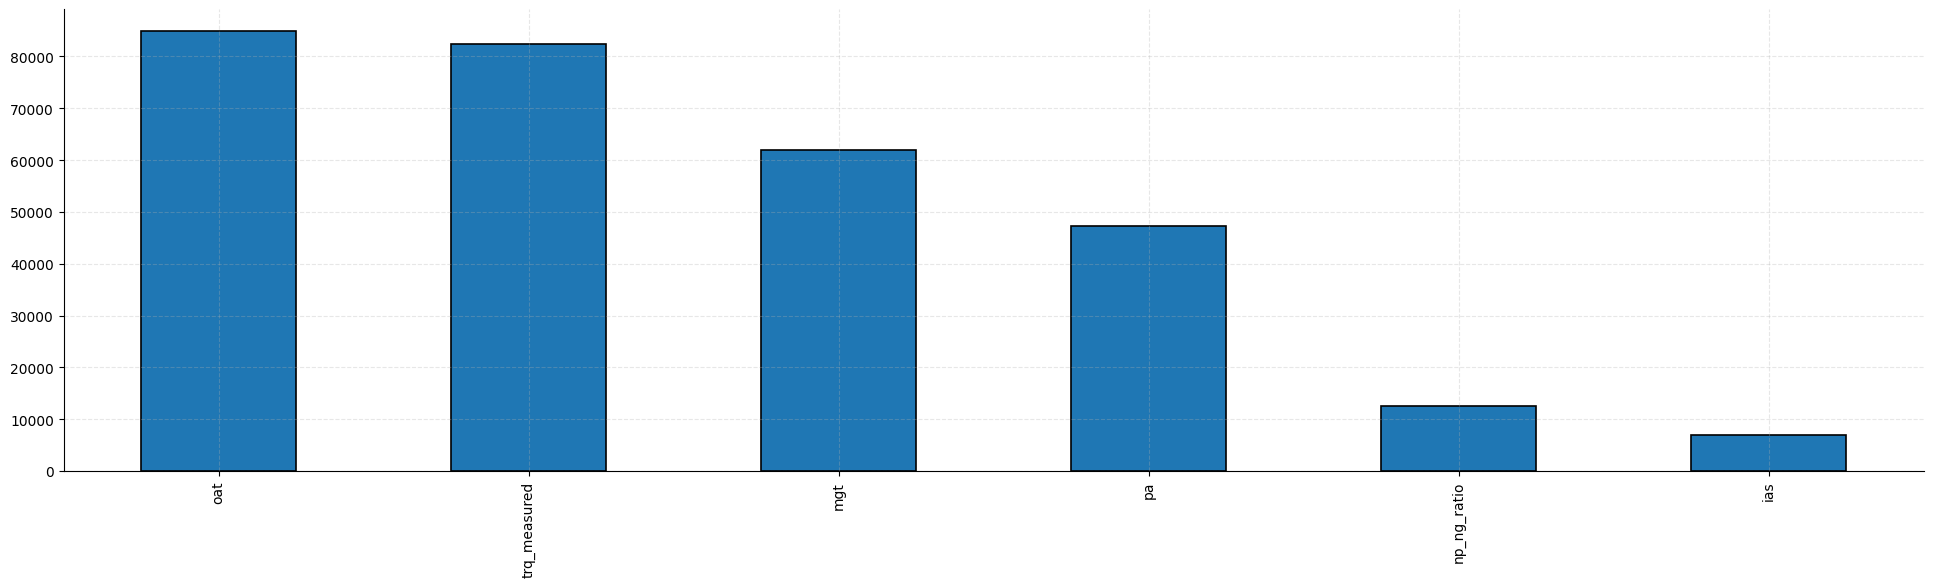

In [26]:
prova=train_df.copy()
F, p_values = f_regression(prova.drop(['trq_target','faulty','trq_margin'],axis=1), train_df['trq_margin'])
f_scores_margin = pd.Series(F, index=prova.drop(['trq_target','faulty','trq_margin'],axis=1).columns).sort_values(ascending=False)
f_scores.plot(kind='bar', figsize=(24, 6))

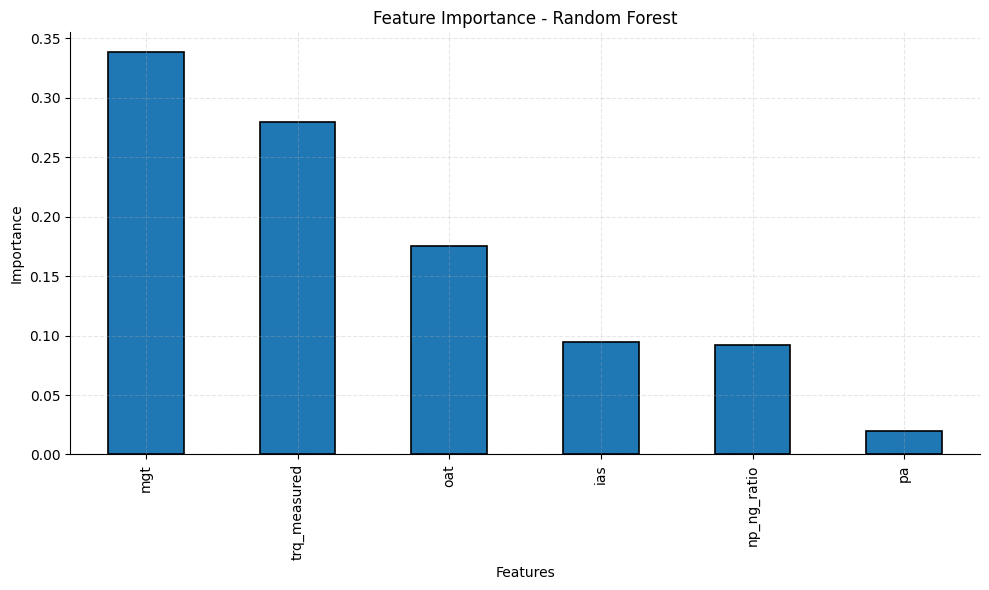

In [23]:
X_train = train_df[FEUTURE].values
y_train = train_df[TARGET_COL_MARGIN].values

X_test = test_df[FEUTURE].values
y_test= test_df[TARGET_COL_MARGIN].values

rf = RandomForestRegressorModel(
    n_estimators=500,
    min_samples_leaf=5,

)
rf.fit(X_train, y_train)

importances_margin = rf.model.feature_importances_
feat_imp_margin = pd.Series(importances, index=FEUTURE)
feat_imp_margin = feat_imp.sort_values(ascending=False)

plt.figure(figsize=(10, 6))
feat_imp_margin.plot(kind='bar')
plt.title("Feature Importance - Random Forest")
plt.ylabel("Importance")
plt.xlabel("Features")
plt.tight_layout()
plt.show()

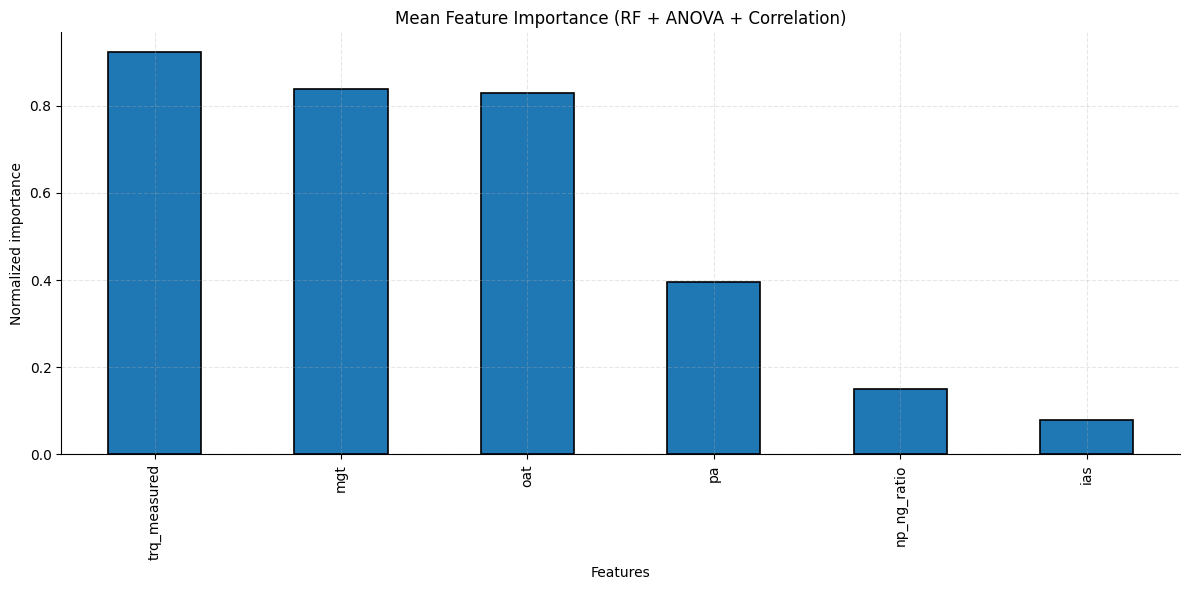

In [27]:
feat_imp_margin.name = "RF"
f_scores_margin.name = "ANOVA"
corr_with_margin.name = "Correlation"

feat_compare = pd.concat(
    [feat_imp_margin, f_scores_margin, corr_with_margin],
    axis=1
)

scaler = MinMaxScaler()

feat_compare["ANOVA"]=scaler.fit_transform()

feat_compare["Mean_importance"] = feat_compare.mean(axis=1)

feat_compare = feat_compare.sort_values(
    "Mean_importance",
    ascending=False
)

plt.figure(figsize=(12, 6))

feat_compare["Mean_importance"].plot(kind="bar")

plt.title("Mean Feature Importance (RF + ANOVA + Correlation)")
plt.ylabel("Normalized importance")
plt.xlabel("Features")
plt.tight_layout()
plt.show()